In [5]:
import pandas as pd
from sklearn.cluster import KMeans

df_pronto_para_kmeans = pd.read_parquet("sample_data/dataset_limpo.parquet")
df_pronto_para_kmeans.columns = [col.lower() for col in df_pronto_para_kmeans.columns]

dataframe_completo = pd.read_parquet("sample_data/dataset_limpo_antes_normalizacao.parquet")

# Configurando o K-Means
# Defina o número de clusters desejado (k)
numero_de_clusters = 30

# random_state=42 garante que os resultados sejam reproduzíveis a cada execução
modelo_kmeans = KMeans(n_clusters=numero_de_clusters, random_state=42)

# Aplicando o K-Means
clusters_kmeans = modelo_kmeans.fit_predict(df_pronto_para_kmeans)

# Salvando no dataframe original
dataframe_completo['cluster_kmeans'] = clusters_kmeans

# Exibindo os resultados
print(f"Distribuição dos pontos por Cluster (K-Means com k={numero_de_clusters}):")
print("Nota: No K-Means, todos os pontos são alocados em um cluster. Não há representação de ruído (-1).")
print(dataframe_completo['cluster_kmeans'].value_counts().sort_index())

/Users/marcosgregorio/codigos/pgp_trabalho/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Distribuição dos pontos por Cluster (K-Means com k=30):
Nota: No K-Means, todos os pontos são alocados em um cluster. Não há representação de ruído (-1).
cluster_kmeans
0     9383
1     2294
2     6504
3     2142
4        8
5     4722
6        1
7     1450
8     4054
9     3044
10    1794
11     967
12    3990
13    4759
14    4413
15     426
16    1838
17     880
18    3228
19    4987
20    3432
21    5188
22    6395
23      81
24       5
25    3293
26    2419
27    1086
28    1994
29    1074
Name: count, dtype: int64


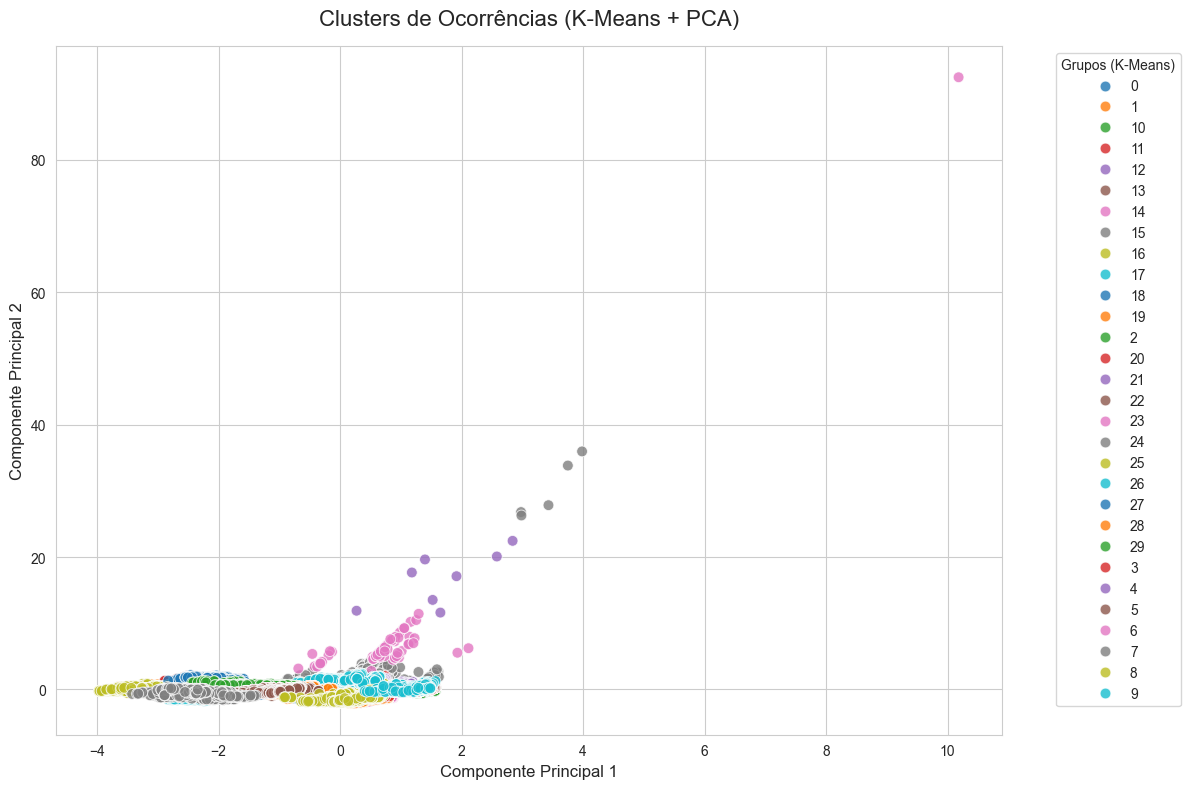

In [6]:
# ==========================================
# CÉLULA: VISUALIZAÇÃO DOS CLUSTERS EM 2D (K-MEANS)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Redução de dimensionalidade para 2D usando PCA
# Assumindo que df_pronto_para_kmeans é o dataset que você usou no fit_predict
pca = PCA(n_components=2)
dados_2d = pca.fit_transform(df_pronto_para_kmeans)

# Preparando o dataframe para o plot
df_plot = dataframe_completo.copy()
df_plot['Eixo_X'] = dados_2d[:, 0]
df_plot['Eixo_Y'] = dados_2d[:, 1]

# Transformando a saída do K-Means em texto (categoria) para garantir cores distintas no gráfico
df_plot['cluster_kmeans'] = df_plot['cluster_kmeans'].astype(str)

# Ordenando os clusters para que a legenda fique sequencial (0, 1, 2...)
df_plot = df_plot.sort_values('cluster_kmeans')

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Plotando todos os clusters de uma vez, já que não há ruído
sns.scatterplot(
    data=df_plot, 
    x='Eixo_X', 
    y='Eixo_Y',
    hue='cluster_kmeans', 
    palette='tab10', 
    alpha=0.8, 
    s=60
)

plt.title('Clusters de Ocorrências (K-Means + PCA)', fontsize=16, pad=15)
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupos (K-Means)')
plt.tight_layout()
plt.show()